In [2]:
!apt-get -qq install -y gnuplot > /dev/null
!gnuplot --version

Extracting templates from packages: 100%
gnuplot 5.4 patchlevel 2


In [3]:
import pandas as pd

df = pd.read_csv("dengue_dataset_simulado.csv")
print(f"CSV leido: {len(df)} filas")

CSV leido: 2496 filas


In [4]:
g1 = df.groupby("fecha_inicio_semana", as_index=False)["casos_confirmados"].sum()
g1 = g1.sort_values("fecha_inicio_semana")
with open("g1_curva.dat", "w") as f:
    f.write("# fecha  casos_confirmados\n")
    for _, r in g1.iterrows():
        f.write(f"{r.fecha_inicio_semana}\t{int(r.casos_confirmados)}\n")
print(f"G1 -> g1_curva.dat ({len(g1)} filas)")

G1 -> g1_curva.dat (156 filas)


In [5]:
gnuplot_script = r"""set terminal pngcairo size 1200,800 enhanced font "Arial,14" background rgb "#0E1A2B"
set output "g1_curva.png"

set border lc rgb "#5A6E85"
set key textcolor rgb "#D6E1EE"
set title textcolor rgb "#38BDF8"
set xlabel textcolor rgb "#D6E1EE"
set ylabel textcolor rgb "#D6E1EE"
set tics textcolor rgb "#A9B8C9"

set title "Casos semanales de dengue en 16 distritos del Peru (2023-2025)" font "Arial,18"
set xlabel "Semana epidemiologica"
set ylabel "Casos confirmados"

set xdata time
set timefmt "%Y-%m-%d"
set format x "%b\n%Y"
set xtics 7776000

set grid ytics lc rgb "#24374F" lw 1
set yrange [0:*]

set label 1 "Pico: SE 12 de 2023\n1 559 casos" at "2023-03-19", 1559 \
    offset 1.5,1.2 textcolor rgb "#FBBF24" font "Arial,13"
set arrow 1 from "2023-03-19", 1559 to "2023-03-19", 1450 nohead lc rgb "#FBBF24" lw 2

plot "g1_curva.dat" using 1:2 with lines lw 3 lc rgb "#38BDF8" \
     title "Casos confirmados"
"""

with open("g1_plot.gp", "w") as file:
    file.write(gnuplot_script)

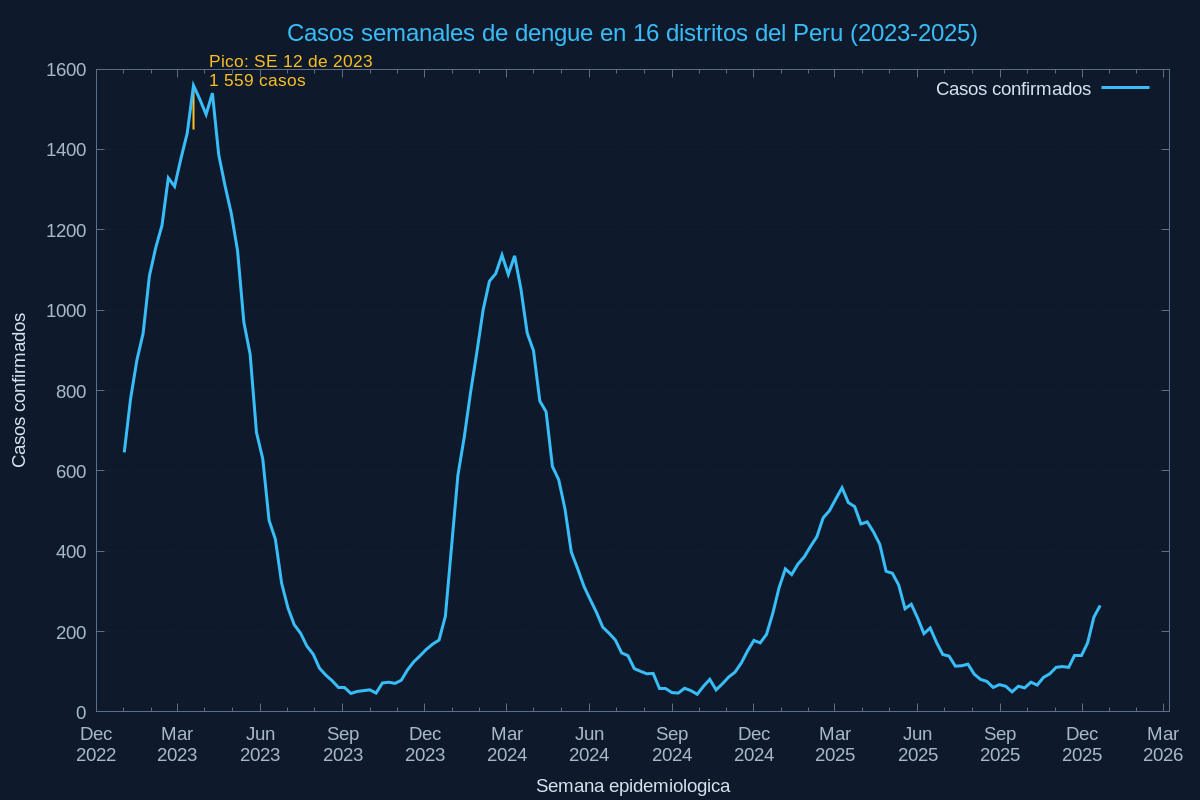

In [6]:
!gnuplot g1_plot.gp

from IPython.display import Image
Image("g1_curva.png")

In [7]:
# G2 - superficie clima/mosquito
g2 = df[["temperatura_media_c","indice_aedico_pct","tasa_incidencia_100k"]].copy()
g2 = g2[g2.tasa_incidencia_100k < 120]
with open("g2_superficie.dat","w") as f:
    for _, r in g2.iterrows():
        f.write(f"{r.temperatura_media_c}\t{r.indice_aedico_pct}\t{r.tasa_incidencia_100k}\n")


In [11]:
gnuplot_script = r"""set terminal pngcairo size 1200,850 enhanced font "Arial,14" background rgb "#0E1A2B"
set output "g2_superficie.png"

set border lc rgb "#5A6E85"
set title textcolor rgb "#38BDF8"
set xlabel textcolor rgb "#D6E1EE"
set ylabel textcolor rgb "#D6E1EE"
set zlabel textcolor rgb "#D6E1EE"
set tics textcolor rgb "#A9B8C9"
unset key

set title "Superficie de riesgo: el brote se dispara cuando el calor\ny la densidad del mosquito coinciden" font "Arial,17"
set xlabel "Temperatura media (C)" rotate parallel offset 0,-1
set ylabel "Indice aedico (% de viviendas con larvas)" rotate parallel offset 0,-1
set zlabel "Tasa de incidencia (casos por 100 000 hab.)" rotate parallel offset -2,0

set dgrid3d 40,40 gauss 0.8,1.5
set pm3d
set hidden3d
set palette defined (0 "#0B3D63", 0.4 "#1C7293", 0.7 "#38BDF8", 1 "#FBBF24")
set view 55, 320
set ticslevel 0
set grid lc rgb "#24374F"

splot "g2_superficie.dat" using 1:2:3 with pm3d
"""

with open("g2_plot.gp", "w") as file:
    file.write(gnuplot_script)

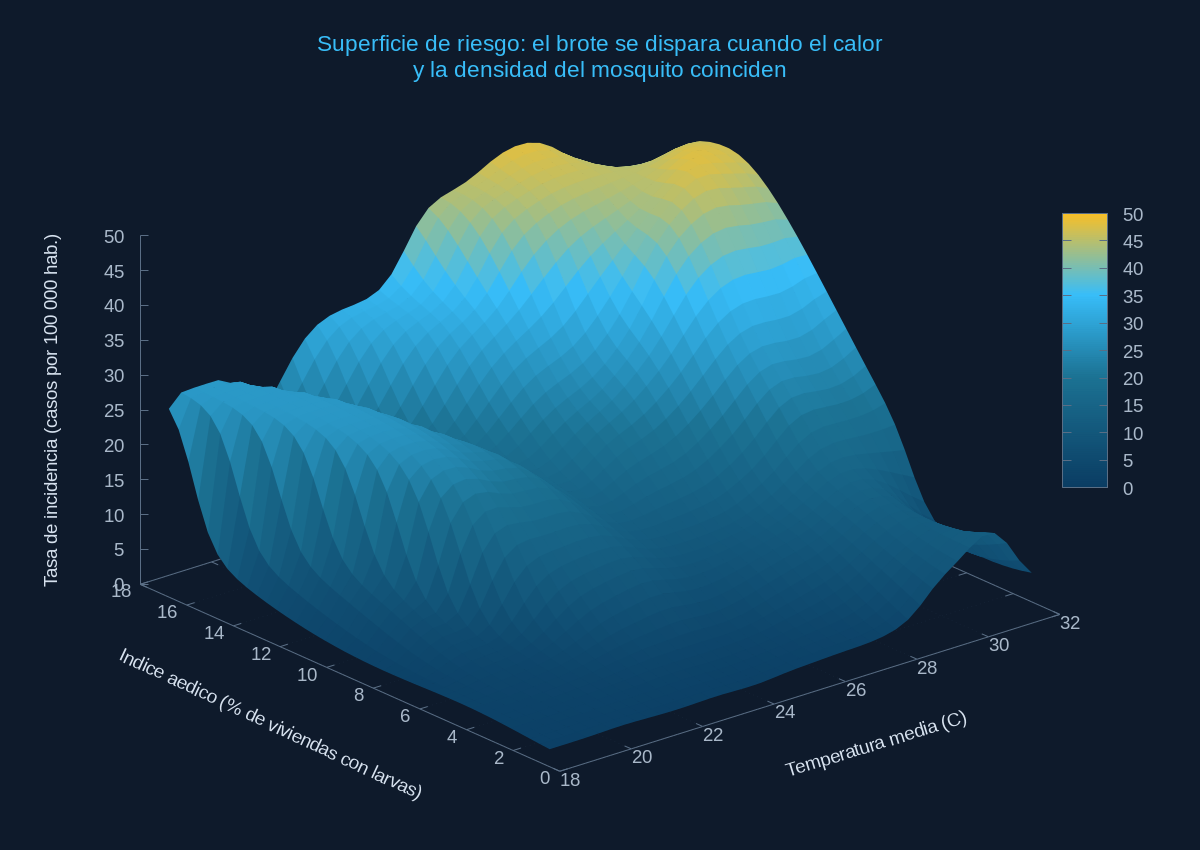

In [15]:
!gnuplot g2_plot.gp

from IPython.display import Image
Image("g2_superficie.png")

In [8]:
# G3 - real vs predicho (validacion 2023-2024)
val = df[df.anio.isin([2023,2024])]
g3 = (val.groupby("fecha_inicio_semana", as_index=False)
         [["casos_confirmados","casos_predichos_modelo"]].sum()
         .sort_values("fecha_inicio_semana"))
with open("g3_real_vs_predicho.dat","w") as f:
    for _, r in g3.iterrows():
        f.write(f"{r.fecha_inicio_semana}\t{int(r.casos_confirmados)}\t{int(r.casos_predichos_modelo)}\n")


In [12]:
gnuplot_script = r"""set terminal pngcairo size 1200,800 enhanced font "Arial,14" background rgb "#0E1A2B"
set output "g3_real_vs_predicho.png"

set border lc rgb "#5A6E85"
set key textcolor rgb "#D6E1EE" top right box lc rgb "#24374F"
set title textcolor rgb "#38BDF8"
set xlabel textcolor rgb "#D6E1EE"
set ylabel textcolor rgb "#D6E1EE"
set tics textcolor rgb "#A9B8C9"

set title "El modelo sigue la curva real: validacion 2023-2024 (R2 = 0,94)" font "Arial,18"
set xlabel "Semana epidemiologica"
set ylabel "Casos por semana"

set xdata time
set timefmt "%Y-%m-%d"
set format x "%b\n%Y"
set xtics 5184000
set grid ytics lc rgb "#24374F" lw 1
set yrange [0:*]

plot "g3_real_vs_predicho.dat" using 1:2 with lines lw 3 lc rgb "#38BDF8" \
        title "Casos reales", \
     "" using 1:3 with lines lw 2.5 dt 2 lc rgb "#FBBF24" \
        title "Casos predichos por el modelo"
"""

with open("g3_plot.gp", "w") as file:
    file.write(gnuplot_script)

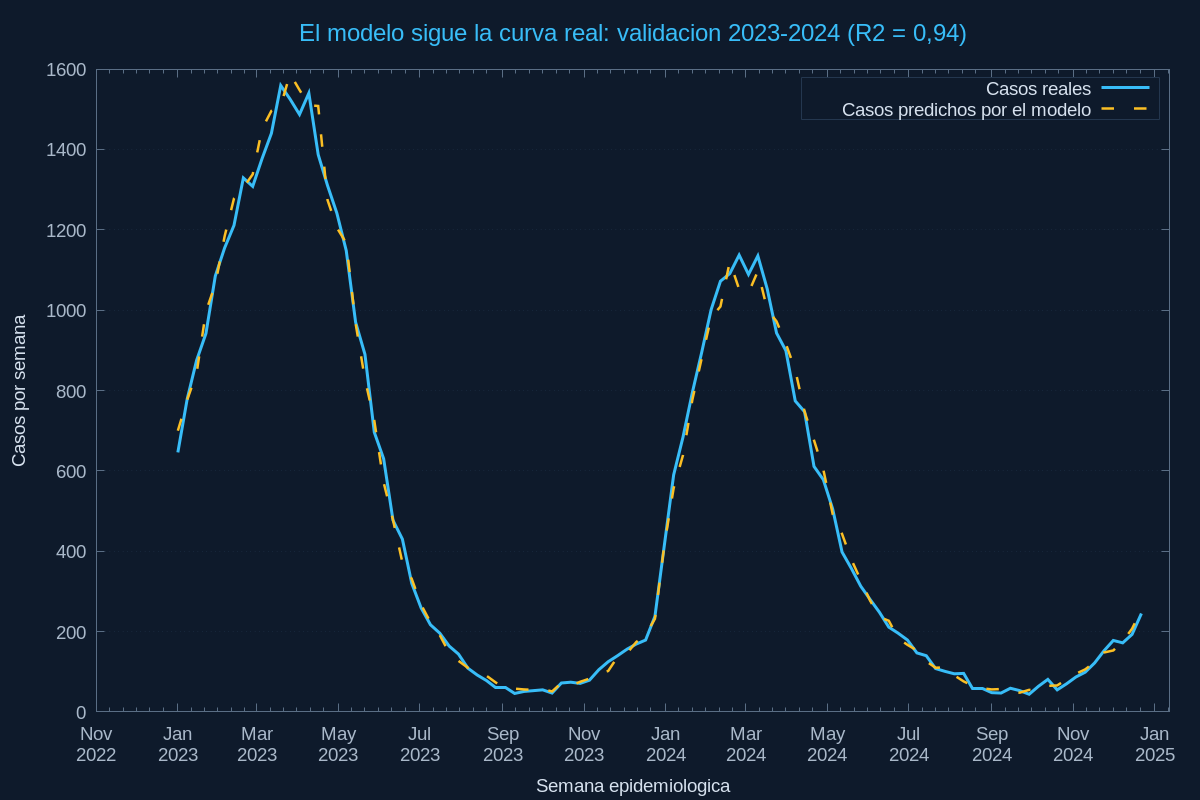

In [16]:
!gnuplot g3_plot.gp

from IPython.display import Image
Image("g3_real_vs_predicho.png")

In [9]:
# G4 - impacto 2025 por departamento
d25 = df[df.anio == 2025]
g4 = (d25.groupby("departamento", as_index=False)
         [["casos_esperados_sin_intervencion","casos_confirmados"]].sum()
         .sort_values("casos_esperados_sin_intervencion", ascending=False))
with open("g4_impacto.dat","w") as f:
    for _, r in g4.iterrows():
        # comillas obligatorias: sin ellas gnuplot parte "La Libertad" en dos
        f.write(f'"{r.departamento}"\t{int(r.casos_esperados_sin_intervencion)}\t{int(r.casos_confirmados)}\n')


In [13]:
gnuplot_script = r"""set terminal pngcairo size 1200,800 enhanced font "Arial,14" background rgb "#0E1A2B"
set output "g4_impacto.png"

set border lc rgb "#5A6E85"
set key textcolor rgb "#D6E1EE" top right box lc rgb "#24374F"
set title textcolor rgb "#38BDF8"
set xlabel textcolor rgb "#D6E1EE"
set ylabel textcolor rgb "#D6E1EE"
set tics textcolor rgb "#A9B8C9"

set title "Casos esperados sin intervencion frente a casos observados (2025)" font "Arial,18"
set ylabel "Casos de dengue"
set xlabel "Departamento"

set style data histogram
set style histogram clustered gap 1
set style fill solid 0.9 border rgb "#0E1A2B"
set boxwidth 0.85
set grid ytics lc rgb "#24374F" lw 1
set yrange [0:5000]
set xtics nomirror

plot "g4_impacto.dat" using 2:xtic(1) lc rgb "#FBBF24" \
        title "Esperados sin intervencion", \
     "" using 3 lc rgb "#38BDF8" title "Observados con intervencion"
"""

with open("g4_plot.gp", "w") as file:
    file.write(gnuplot_script)

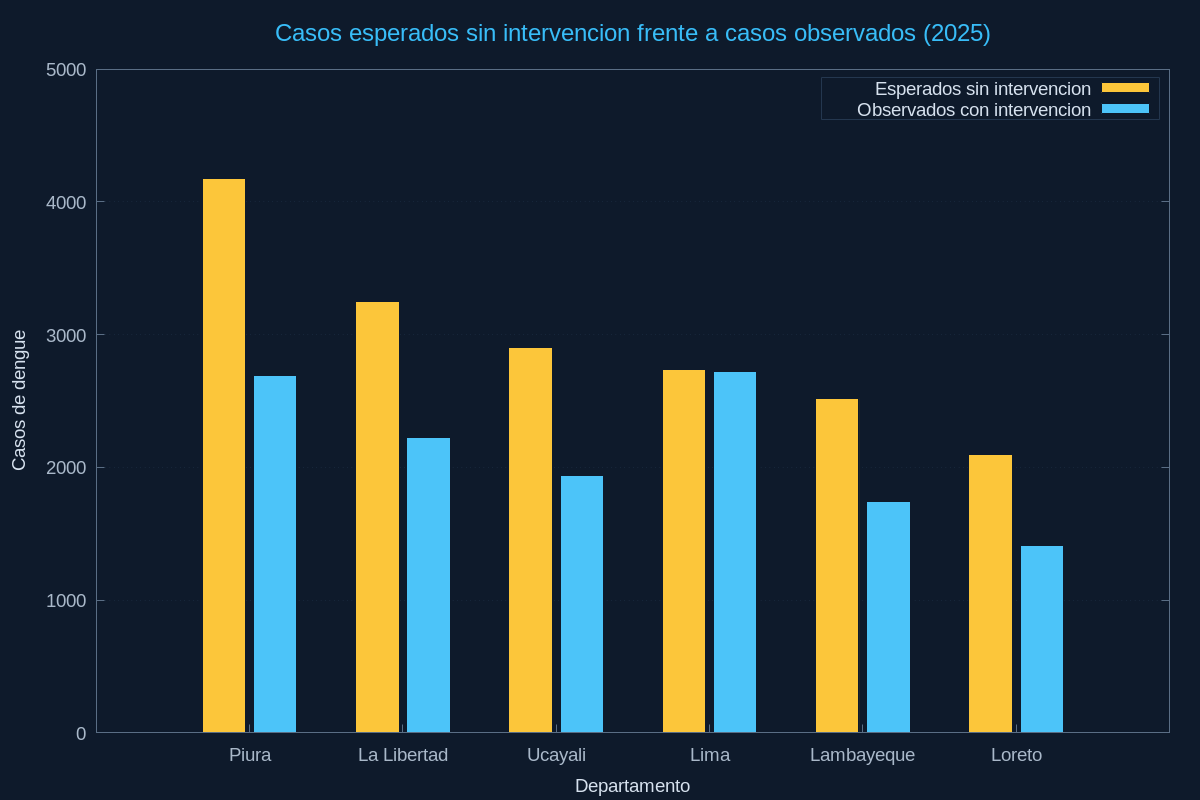

In [17]:
!gnuplot g4_plot.gp

from IPython.display import Image
Image("g4_impacto.png")

In [10]:
# G5 - superficie distrito x semana
piv = df.groupby(["distrito","semana_epidemiologica"], as_index=False)["tasa_incidencia_100k"].mean()
orden = df.groupby("distrito")["tasa_incidencia_100k"].mean().sort_values().index.tolist()
with open("g5_superficie.dat","w") as f:
    for i, dist in enumerate(orden, start=1):
        sub = piv[piv.distrito == dist].sort_values("semana_epidemiologica")
        for _, r in sub.iterrows():
            f.write(f"{i}\t{int(r.semana_epidemiologica)}\t{r.tasa_incidencia_100k:.2f}\n")
        f.write("\n")   # linea en blanco: separa los bloques de la malla

In [14]:
gnuplot_script = r"""set terminal pngcairo size 1250,850 enhanced font "Arial,13" background rgb "#0E1A2B"
set output "g5_superficie.png"

set border lc rgb "#5A6E85"
set title textcolor rgb "#38BDF8"
set xlabel textcolor rgb "#D6E1EE"
set ylabel textcolor rgb "#D6E1EE"
set zlabel textcolor rgb "#D6E1EE"
set tics textcolor rgb "#A9B8C9"
unset key

set title "El riesgo no es uniforme: se concentra en distritos y semanas concretos\n(incidencia media por 100 000 habitantes, 2023-2025)" font "Arial,16"
set ylabel "Semana epidemiologica" rotate parallel offset 0,-1
set zlabel "Incidencia por 100 000 hab." rotate parallel offset -2,0

set xtics ("Comas" 1, "Villa El Salvador" 2, "San Juan de Lurigancho" 3, \
           "Trujillo" 4, "La Esperanza" 5, "Chiclayo" 6, "El Porvenir" 7, \
           "Jose Leonardo Ortiz" 8, "Castilla" 9, "Iquitos" 10, "Sullana" 11, \
           "Piura" 12, "Catacaos" 13, "Calleria" 14, "Yarinacocha" 15, \
           "Belen" 16) rotate by 50 right font "Arial,10"

set pm3d
set hidden3d
set palette defined (0 "#0B3D63", 0.35 "#1C7293", 0.65 "#38BDF8", 1 "#FBBF24")
set view 58, 300
set ticslevel 0
set ytics 8
set cblabel "Incidencia" textcolor rgb "#D6E1EE"

splot "g5_superficie.dat" using 1:2:3 with pm3d
"""

with open("g5_plot.gp", "w") as file:
    file.write(gnuplot_script)

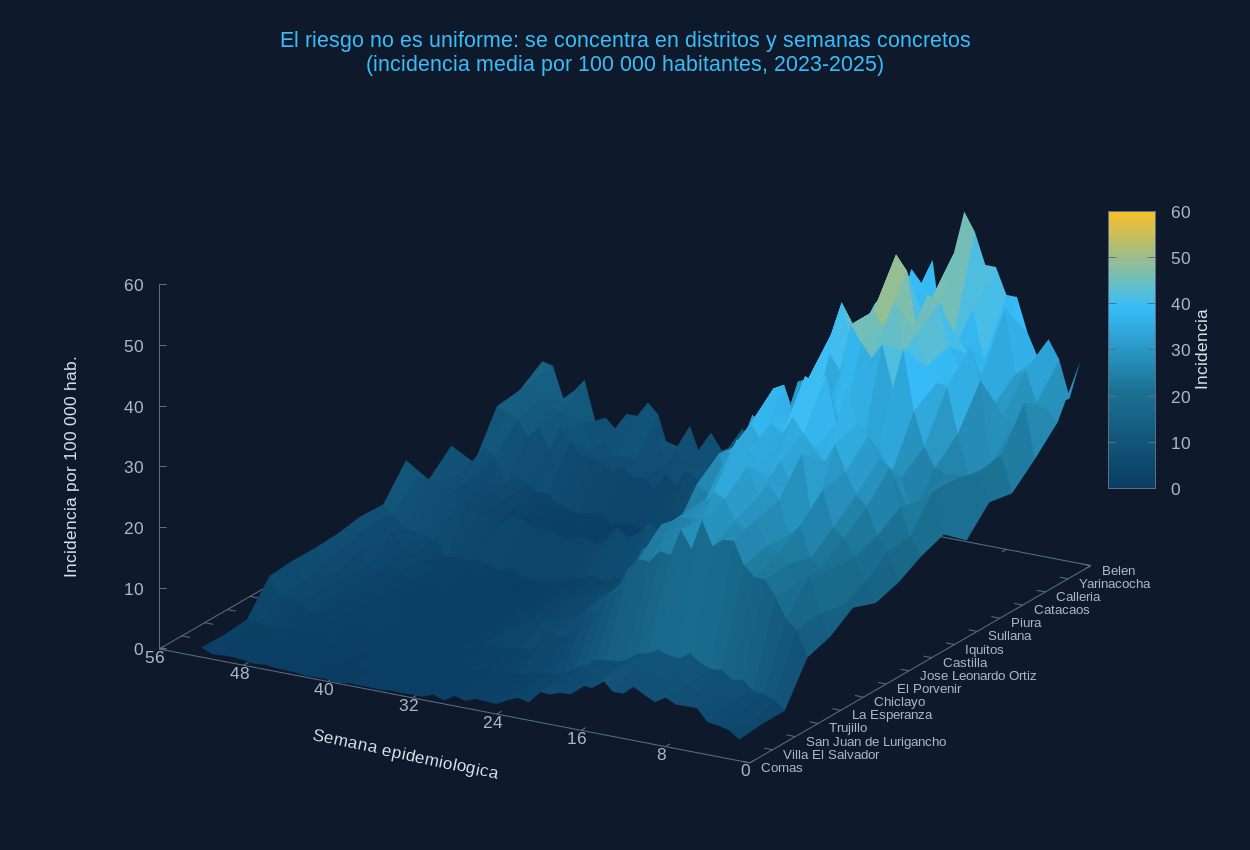

In [18]:
!gnuplot g5_plot.gp

from IPython.display import Image
Image("g5_superficie.png")